Index(['Country', 2006, 2007, 2008, 2009, 2011, 2012, 2016, 2017], dtype='object')


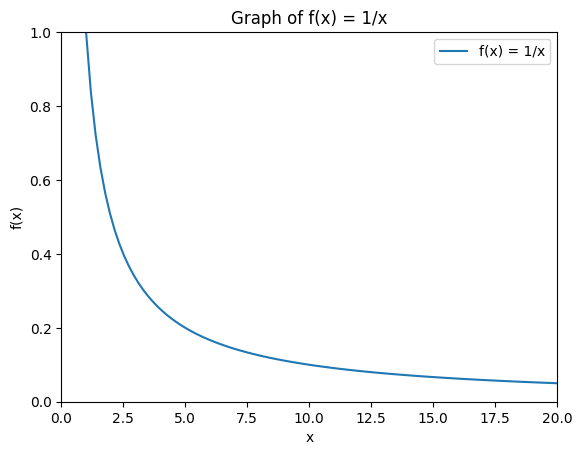

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

x = np.linspace(1, 20, 100)
y = 1/x

plt.figure()
plt.plot(x, y, label='f(x) = 1/x')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('Graph of f(x) = 1/x')

plt.axis([0, 20, 0, 1])

plt.legend()
plt.show()

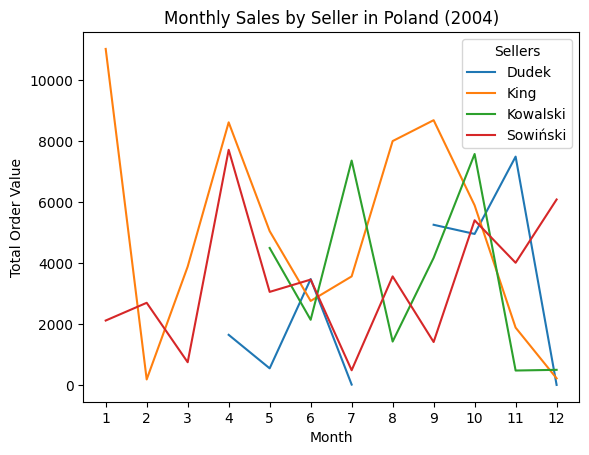

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df_ord = pd.read_csv('orders.csv', sep=';')
df_ord['OrderDate'] = pd.to_datetime(df_ord['OrderDate'])

df_2004_pl = df_ord[(df_ord['OrderDate'].dt.year == 2004) & (df_ord['Country'] == 'Polska')].copy()

df_2004_pl['Month'] = df_2004_pl['OrderDate'].dt.month

grouped = df_2004_pl.groupby(['Seller', 'Month'])['OrderValue'].sum().unstack(level=0)

grouped.plot()
plt.title('Monthly Sales by Seller in Poland (2004)')
plt.xlabel('Month')
plt.ylabel('Total Order Value')
plt.xticks(range(1, 13))
plt.legend(title='Sellers')
plt.show()

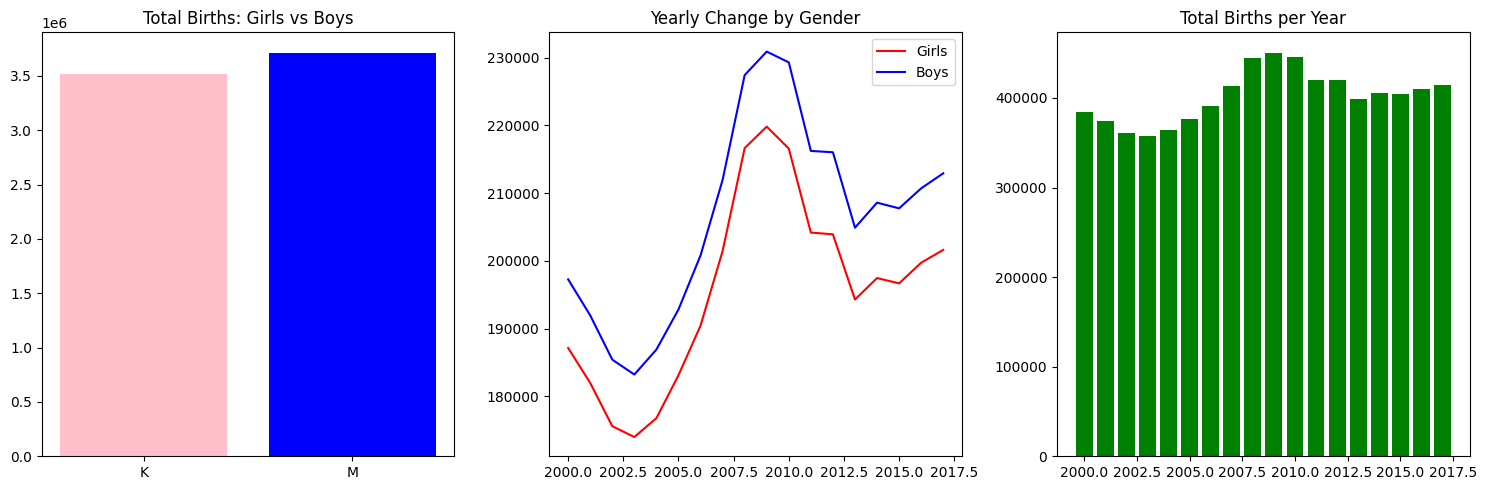

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

df_names = pd.read_excel('names.xlsx') 

plt.figure(figsize=(15, 5))

# 3.1
plt.subplot(1, 3, 1)
gender_counts = df_names.groupby('Gender')['Count'].sum()
plt.bar(gender_counts.index, gender_counts.values, color=['pink', 'blue'])
plt.title('Total Births: Girls vs Boys')

# 3.2
plt.subplot(1, 3, 2)
girls = df_names[df_names['Gender'] == 'K'].groupby('Year')['Count'].sum()
boys = df_names[df_names['Gender'] == 'M'].groupby('Year')['Count'].sum()
plt.plot(girls.index, girls.values, label='Girls', color='red')
plt.plot(boys.index, boys.values, label='Boys', color='blue')
plt.legend()
plt.title('Yearly Change by Gender')

# 3.3
plt.subplot(1, 3, 3)
total_yearly = df_names.groupby('Year')['Count'].sum()
plt.bar(total_yearly.index, total_yearly.values, color='green')
plt.title('Total Births per Year')

plt.tight_layout()
plt.show()

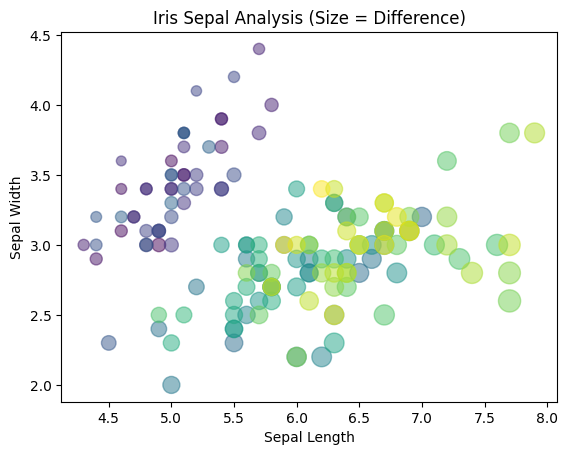

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

url = "https://archive.ics.uci.edu/ml/machine-learning-databases/iris/iris.data"
columns = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'class']
df_iris = pd.read_csv(url, names=columns)

c = np.arange(len(df_iris))
s = np.abs(df_iris['sepal_length'] - df_iris['sepal_width']) * 50 

plt.figure()
plt.scatter(df_iris['sepal_length'], df_iris['sepal_width'], c=c, s=s, alpha=0.5)
plt.xlabel('Sepal Length')
plt.ylabel('Sepal Width')
plt.title('Iris Sepal Analysis (Size = Difference)')
plt.show()

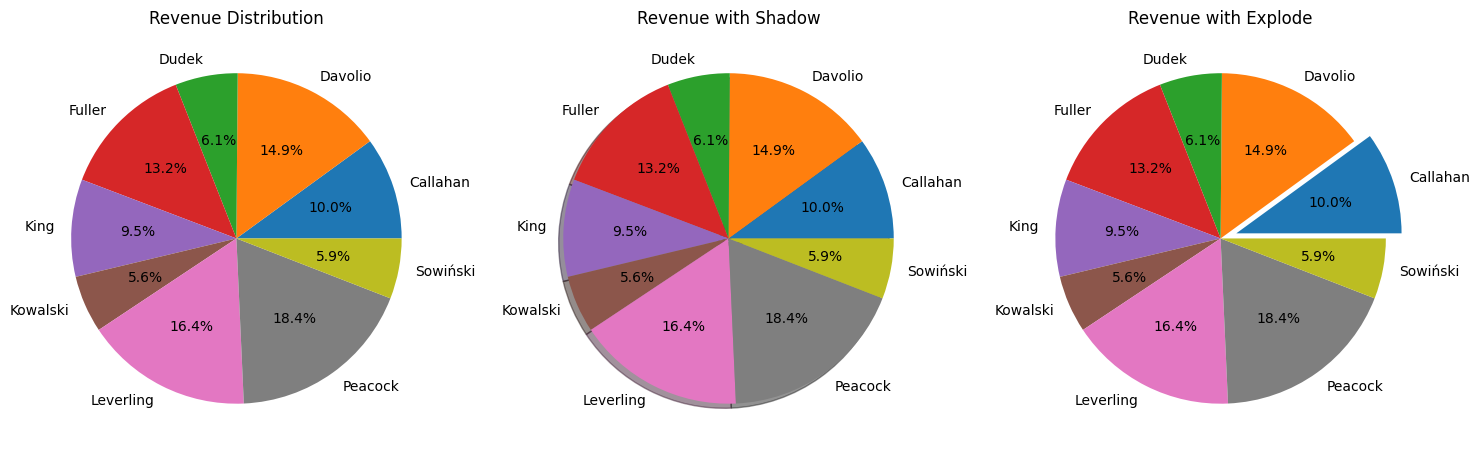

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

df_ord = pd.read_csv('orders.csv', sep=';')
seller_values = df_ord.groupby('Seller')['OrderValue'].sum()

plt.figure(figsize=(15, 5))

# 1. 
plt.subplot(1, 3, 1)
plt.pie(seller_values, labels=seller_values.index, autopct='%1.1f%%')
plt.title('Revenue Distribution')

# 2. 
plt.subplot(1, 3, 2)
plt.pie(seller_values, labels=seller_values.index, autopct='%1.1f%%', shadow=True)
plt.title('Revenue with Shadow')

# 3. 
plt.subplot(1, 3, 3)
explode = [0.1 if i == 0 else 0 for i in range(len(seller_values))] 
plt.pie(seller_values, labels=seller_values.index, autopct='%1.1f%%', explode=explode)
plt.title('Revenue with Explode')

plt.tight_layout()
plt.show()